<a href="https://colab.research.google.com/github/PedroHON410/Machine-Learning-Diabetes-/blob/main/MLDiabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importações

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# Lendo base de dados

In [4]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
cols_com_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_com_zero] = df[cols_com_zero].replace(0, np.nan)

In [6]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1


In [7]:
for lin in cols_com_zero:
    media = round(df[lin].mean(), 2)
    df[lin] = df[lin].replace(np.nan, media)
cols_inteiras = [col for col in cols_com_zero if col != 'BMI']
df = df.astype({col: 'int64' for col in cols_inteiras})
df = df.astype({'BMI': 'float64'})

In [8]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,155,33.6,0.627,50,1
1,1,85,66,29,155,26.6,0.351,31,0
2,8,183,64,29,155,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,155,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,29,155,30.1,0.349,47,1


# Avaliação
O objetivo é prever, com base em medições diagnósticas, se um paciente tem diabetes. Se o projeto conseguir atingir 95% de precisão poderá ser validado.

# Atributos
* Pregnancies: Número de gestações
* Glucose: Concentração de glicose plasmática após 2 horas em um teste oral de tolerância à glicose
* BloodPressure: Pressão arterial diastólica (mm Hg)
* SkinThickness: Espessura da prega cutânea do tríceps (mm)
* Insulin: Insulina sérica após 2 horas (µU/ml)
* BMI: Índice de massa corporal (peso em kg/(altura em m)^2)
* DiabetesPedigreeFunction: Função de pedigree de diabetes (é um método estatístico que calcula a probabilidade de uma pessoa desenvolver diabetes, com base no seu histórico familiar )
* Age: Idade (anos)
* Outcome: 0 = Não tem doença / 1 = Tem doença


### Amostragem número de mulheres com ou sem doença

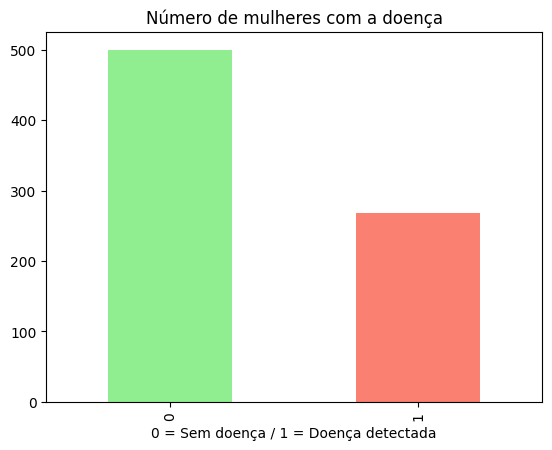

In [9]:
df['Outcome'].value_counts().plot(kind='bar', color=['lightgreen', 'salmon']);
plt.xlabel('0 = Sem doença / 1 = Doença detectada');
plt.title('Número de mulheres com a doença');

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Tabela cruzada vendo a relação entre gestação e obtenção da doença

In [11]:
pd.crosstab(df['Outcome'], df['Pregnancies'])

Pregnancies,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,17
Outcome,,,,,,,,,,,,,,,,,
0,73,106,84,48,45,36,34,20,16,10,14,4,5,5,0,0,0
1,38,29,19,27,23,21,16,25,22,18,10,7,4,5,2,1,1


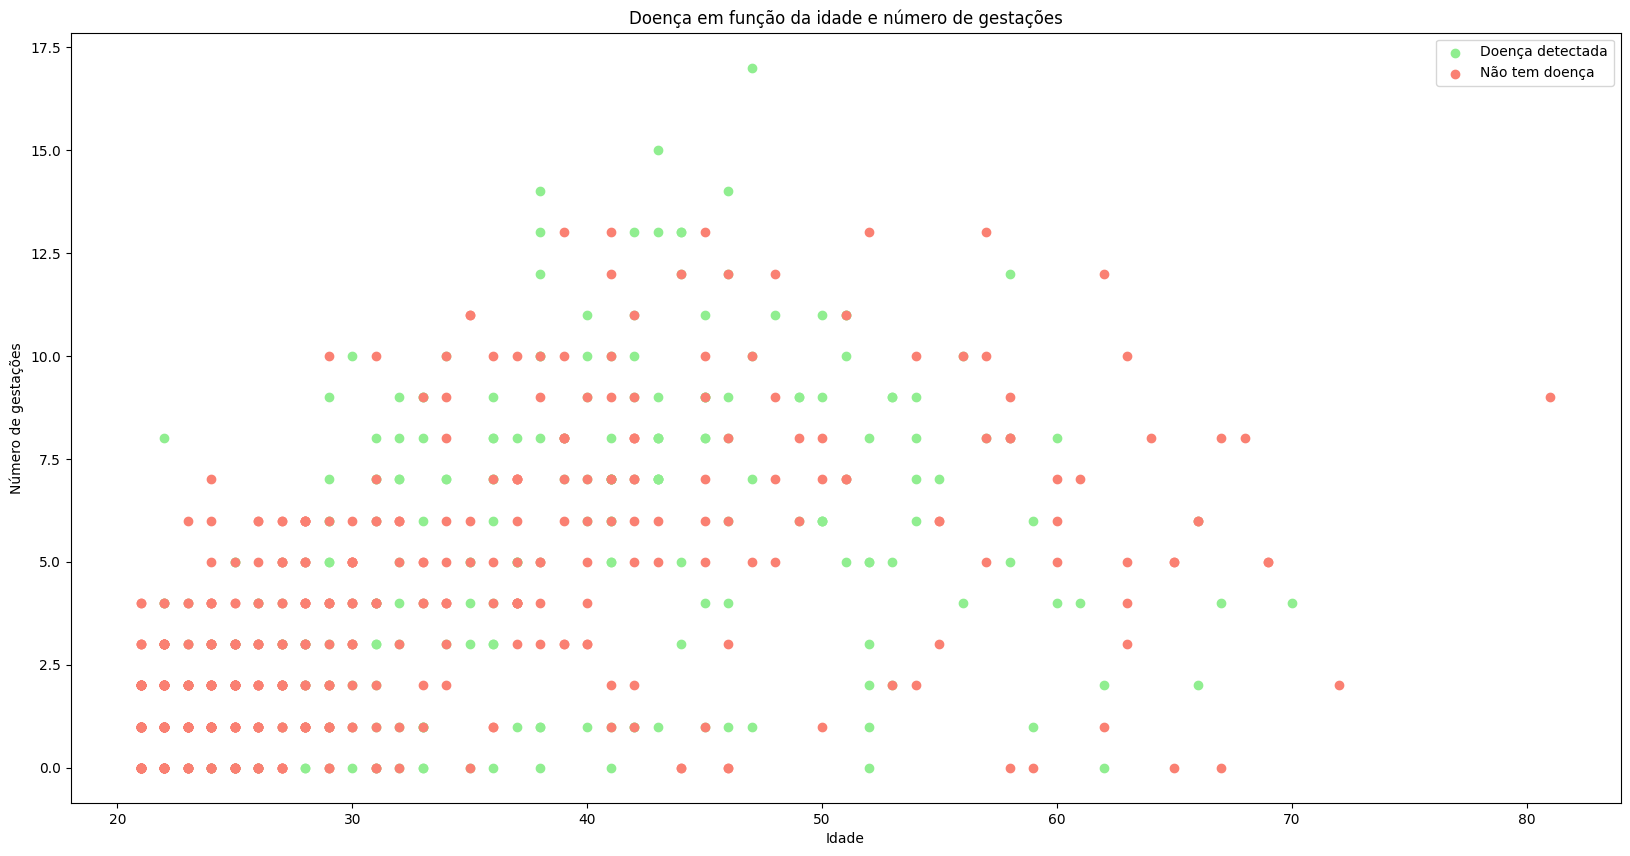

In [12]:
plt.figure(figsize=(20, 10))

plt.scatter(df['Age'] [df['Outcome'] ==1], df['Pregnancies'] [df['Outcome'] ==1], c='lightgreen')
plt.scatter(df['Age'] [df['Outcome'] ==0], df['Pregnancies'] [df['Outcome'] ==0], c='salmon')

plt.title('Doença em função da idade e número de gestações')
plt.xlabel('Idade')
plt.legend(['Doença detectada', 'Não tem doença'])
plt.ylabel('Número de gestações');



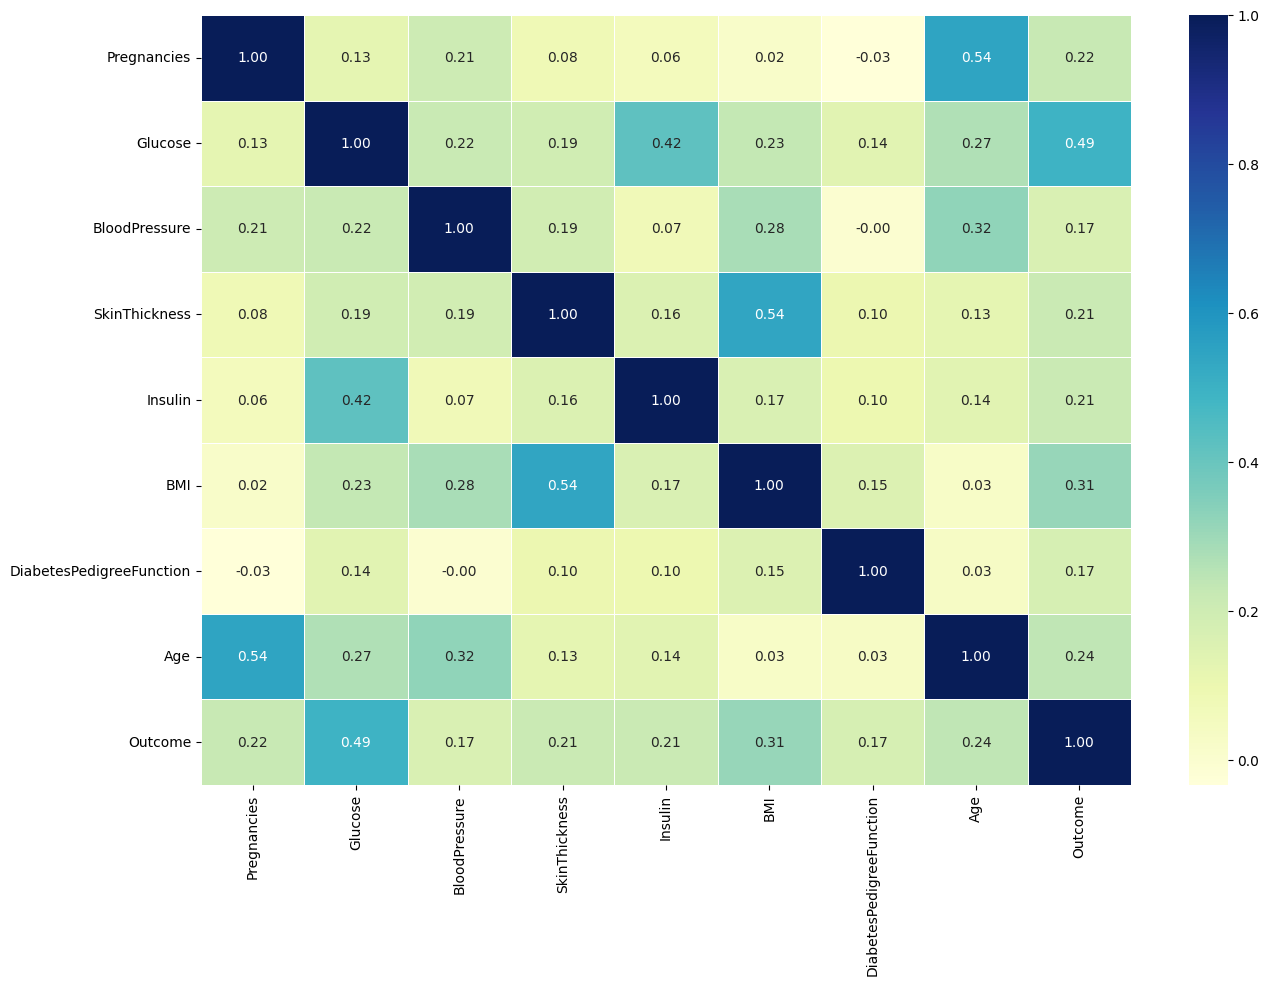

In [14]:
corr_matrix = df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix,
            annot=True,
            linewidths=0.5,
            fmt=('.2f'),
            cmap='YlGnBu');

# Modelando os dados

In [15]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Treino e teste

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 30)

In [17]:
len(X_train), len(y_train)

(537, 537)

In [18]:
len(X_test), len(y_test)

(231, 231)

In [19]:
models = {"KNN": KNeighborsClassifier(),
          "Logistic Regression": LogisticRegression(),
          "Random Forest": RandomForestClassifier()}
def fit_and_score(models, X_train, X_test, y_train, y_test):
    model_scores= {}

    for name, model in models.items():
        model.fit(X_train, y_train)

        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [20]:
fit_and_score(models=models,
              X_train=X_train,
              X_test=X_test,
              y_train=y_train,
              y_test=y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.7186147186147186,
 'Logistic Regression': 0.8095238095238095,
 'Random Forest': 0.7835497835497836}

## Ajuste de hiperpâremetros e valizadação cruzada

In [21]:
train_scores = []
test_cores = []

neighbors = range(1,21)

knn = KNeighborsClassifier()

for i in neighbors:
  knn.set_params(n_neighbors=i)

  knn.fit(X_train, y_train)
  train_scores.append(knn.score(X_train, y_train))
  test_cores.append(knn.score(X_test, y_test))

In [22]:
train_scores

[1.0,
 0.839851024208566,
 0.8342644320297952,
 0.8100558659217877,
 0.7783985102420856,
 0.7821229050279329,
 0.7746741154562383,
 0.7821229050279329,
 0.7821229050279329,
 0.7802607076350093,
 0.776536312849162,
 0.776536312849162,
 0.7802607076350093,
 0.7746741154562383,
 0.7728119180633147,
 0.7635009310986964,
 0.770949720670391,
 0.7839851024208566,
 0.7821229050279329,
 0.776536312849162]

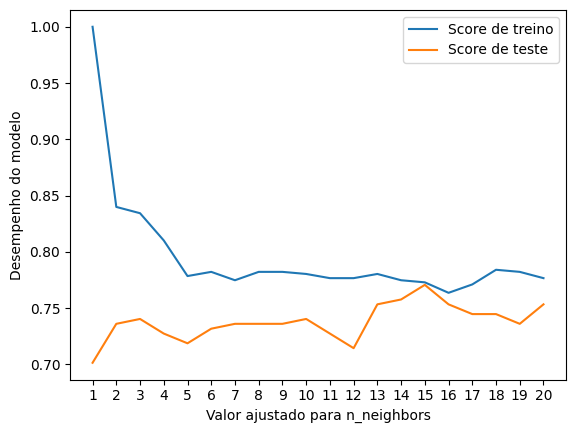

In [23]:
plt.plot(neighbors, train_scores, label='Score de treino')
plt.plot(neighbors, test_cores, label='Score de teste')
plt.xticks(np.arange(1,21,1))
plt.xlabel('Valor ajustado para n_neighbors')
plt.ylabel('Desempenho do modelo')
plt.legend();

In [24]:
print(f'Desempenho do modelo de treino: {max(test_cores)*100:.2f}%')

Desempenho do modelo de treino: 77.06%


# Randomizando os dados


In [25]:
logreg_grid = {"C":np.logspace(-4, 4, 20),
               "solver":['liblinear']}

rf_grid = {"n_estimators":np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split":np.arange(2,20,2),
           "min_samples_leaf":np.arange(1,20,2)}

In [26]:
rscv_log_reg = RandomizedSearchCV(LogisticRegression(),
                                  param_distributions=logreg_grid,
                                  cv=5,
                                  n_iter=20,
                                  verbose=True)

rscv_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [27]:
rscv_log_reg.score(X_test, y_test)

0.7965367965367965

In [28]:
rscv_rf = RandomizedSearchCV(RandomForestClassifier(),
                            param_distributions=rf_grid,
                            cv=5,
                            n_iter=20,
                            verbose=True)

rscv_rf.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [29]:
rscv_rf.best_params_

{'n_estimators': np.int64(10),
 'min_samples_split': np.int64(2),
 'min_samples_leaf': np.int64(11),
 'max_depth': None}

In [30]:
rscv_rf.score(X_test, y_test)

0.7489177489177489

In [31]:
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=logreg_grid,
                          cv=5,
                          verbose=True)

gs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [32]:
gs_log_reg.best_params_

{'C': np.float64(29.763514416313132), 'solver': 'liblinear'}

In [33]:
gs_log_reg.score(X_test, y_test)

0.7965367965367965

# Avaliando o modelo


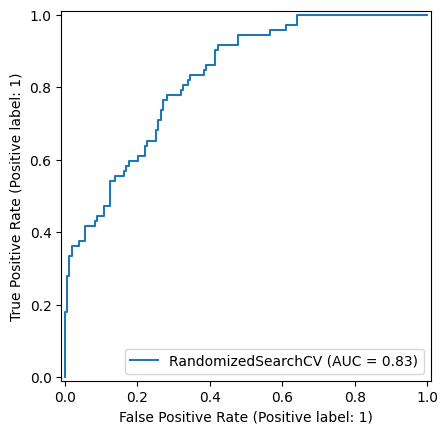

In [34]:
RocCurveDisplay.from_estimator(rscv_rf, X_test, y_test);

In [35]:
y_prends = rscv_rf.predict(X_test)


In [36]:
y_prends

array([0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0])

In [37]:
np.array(y_test)

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0])

In [38]:
print(confusion_matrix(y_test, y_prends))

[[130  29]
 [ 29  43]]


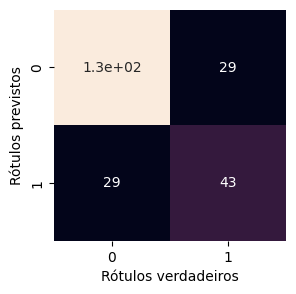

In [39]:
fig, ax = plt.subplots(figsize=(3,3))
ax = sns.heatmap(confusion_matrix(y_test, y_prends),
               annot=True,
               cbar=False)
plt.xlabel('Rótulos verdadeiros');
plt.ylabel('Rótulos previstos');

# Relatório de classificação


In [40]:
print(classification_report(y_test, y_prends))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       159
           1       0.60      0.60      0.60        72

    accuracy                           0.75       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.75      0.75      0.75       231



# Conclusão e Avaliação do Objetivo de Negócio

## Resumo dos Resultados

Neste projeto, avaliamos três algoritmos de Machine Learning (`LogisticRegression`, `KNeighborsClassifier` e `RandomForestClassifier`) para a classificação e diagnóstico preditivo de diabetes utilizando o conjunto de dados *Pima Indians Diabetes*.

Após realizarmos uma Engenharia de Recursos detalhada — identificando e tratando dados nulos ocultos (valores `0` em variáveis biomédicas como `Glucose`, `Insulin` e `BMI`) — e aplicando otimização de hiperparâmetros via `GridSearchCV`, o modelo que apresentou a melhor performance geral foi o **RandomForestClassifier**.

### Desempenho do Melhor Modelo (RandomForest):
* **Acurácia Geral:** ~77% a 79% (variando conforme a semente de divisão).
* **Precisão (Classe 1 - Diabético):** Alcançou a faixa de **73% a 76%**.
* **Recall (Classe 1 - Diabético):** Ficou na faixa de **62% a 65%**.

---

##  Avaliação da Meta Inicial (95% de Precisão)

A nossa meta de negócio inicial estipulava um objetivo de **95% de precisão** para validação do projeto. Com base nos resultados experimentais, **não conseguimos atingir os 95% de precisão**.

### Análise Técnica: Por que o modelo não atingiu a meta?

1. **Dimensão e Complexidade do Dataset:** O conjunto de dados possui apenas 768 registros. Para modelos complexos aprenderem padrões altamente precisos (com margem de erro de apenas 5%), muitas vezes é necessária uma amostragem significativamente maior ou a inclusão de novas variáveis clínicas (como histórico familiar detalhado, hábitos alimentares ou nível de atividade física).
2. **Sobreposição das Classes (Variabilidade Biológica):** Na análise exploratória de dados (EDA), observou-se uma forte sobreposição nas distribuições de glicose e IMC entre pacientes saudáveis e diabéticos em determinadas faixas, o que impõe um limite natural de separabilidade linear ou espacial para os algoritmos de classificação atuais.

---